In [1]:
import jax
import jax.numpy as jnp
from flax import linen as nn
from flax.training import train_state
import optax
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
from functools import partial
import scipy.io
from sklearn.model_selection import train_test_split
import time
import pickle
import torch
import os

## DeepONet Class

In [2]:
class BranchNet(nn.Module):
    features: list

    @nn.compact
    def __call__(self, x):
        init = nn.initializers.glorot_normal()
        
        # #x has shape (ns, nx, ny) - so add channel dimension: (ns, nx, ny, nc)
        x = x[..., jnp.newaxis]

        #2D Convolutional layers and pooling layers
        x = nn.Conv(features = 64, kernel_size = (3,3), strides = (1,1), padding = "SAME")(x)
        x = nn.relu(x)
        x = nn.max_pool(x, window_shape=(2,2), strides = (2,2), padding = "SAME")

        x = nn.Conv(features = 64, kernel_size = (2,2), strides = (1,1), padding = "SAME")(x)
        x = nn.relu(x)
        x = nn.avg_pool(x, window_shape = (2,2), strides = (2,2), padding = "SAME")

        x = x.flatten()   #flattening layer
        for feat in self.features[:-1]:
            x = nn.Dense(feat,kernel_init = init)(x)
            x = nn.tanh(x)
        x = nn.Dense(self.features[-1])(x)
        return x

class TrunkNet(nn.Module):
    features: list

    @nn.compact
    def __call__(self, x):
        init = nn.initializers.glorot_normal()
        for feat in self.features:
            x = nn.Dense(feat,kernel_init = init)(x)
            x = nn.tanh(x)
        return x

class DeepONet(nn.Module):
    branch_features: list
    trunk_features: list
    
    def setup(self):
        self.branch_net = BranchNet(self.branch_features)
        self.trunk_net = TrunkNet(self.trunk_features)

    @nn.compact
    def __call__(self, branch_input, trunk_input):
        branch_out = jax.vmap(self.branch_net, in_axes = 0)(branch_input) 
        trunk_out = jax.vmap(self.trunk_net, in_axes = 0)(trunk_input)     
        output = jnp.einsum('bi,ti->bt', branch_out, trunk_out) 
        bias = self.param('bias', nn.initializers.zeros, (1,))
        output = output + bias
        return output

## Data Preparation

In [3]:
base_path = "/home/dnayak2/data_sgoswam4/Dibya/Datasets/2D_Burgers"
dataset = torch.load(os.path.join(base_path, "Burgers_equation_2D_scalar.pt"))
#inputs = dataset['input_samples']
outputs = dataset['output_samples']
#inputs = jnp.array(inputs)
outputs = jnp.array(outputs)
del dataset

In [ ]:
#data_test = outputs[1000:1500]
outputs = outputs[:1250]
nsamples = outputs.shape[0]
nx = outputs.shape[2]
ny = outputs.shape[3]
nt = outputs.shape[1]
train_time_step = 33


# Split into training and testing dataset
data_train,data_test = train_test_split(outputs,test_size = 0.2,shuffle = False,random_state = 42)
input_train = data_train[:,:train_time_step,:,:]
output_train = data_train[:,1:train_time_step+1,:,:]
print("Original Training Data Shape:",data_train.shape)
print("Original Test Data Shape:",data_test.shape)
print("Original Input Training Data Shape:",input_train.shape)
print("Original Output Training Data Shape:",output_train.shape)
del outputs

# Reshape data
input_train = input_train.reshape(-1,nx,ny)
output_train = output_train.reshape(-1,nx*ny)
print("Reshaped Input Training Data Shape:",input_train.shape)
print("Reshaped Output Training Data Shape:",output_train.shape)

#Splitting into training and validation dataset
input_train,input_valid,output_train,output_valid = train_test_split(input_train,output_train,test_size = 0.2,shuffle = False,random_state = 42)

print("Reshaped Input Training Data Shape:",input_train.shape)
print("Reshaped Output Training Data Shape:",output_train.shape)


Original Training Data Shape: (1000, 101, 32, 32)
Original Test Data Shape: (250, 101, 32, 32)
Original Input Training Data Shape: (1000, 33, 32, 32)
Original Output Training Data Shape: (1000, 33, 32, 32)
Reshaped Input Training Data Shape: (33000, 32, 32)
Reshaped Output Training Data Shape: (33000, 1024)
Reshaped Input Training Data Shape: (26400, 32, 32)
Reshaped Output Training Data Shape: (26400, 1024)


In [5]:
#Form branch and trunk inputs train
xspan = jnp.linspace(0, 1, nx)
yspan = jnp.linspace(0, 1, ny)

#Create for trunk network - a meshgrid of only spatial coordinates
[x,y] = jnp.meshgrid(xspan, yspan, indexing = 'ij')
grid = jnp.transpose(jnp.array([x.flatten(), y.flatten()]))

In [6]:
# Branch and trunk data
branch_train = input_train
trunk_train = grid
don_train = output_train

print("Branch Training Data Shape:",branch_train.shape)
print("Trunk Training Data Shape:",trunk_train.shape)
print("DON Training Data Shape:",don_train.shape)

branch_valid = input_valid
trunk_valid = grid
don_valid = output_valid
print("Branch Validation Data Shape:",branch_valid.shape)
print("Trunk Validation Data Shape:",trunk_valid.shape)
print("DON Validation Data Shape:",don_valid.shape)

Branch Training Data Shape: (26400, 32, 32)
Trunk Training Data Shape: (1024, 2)
DON Training Data Shape: (26400, 1024)
Branch Validation Data Shape: (6600, 32, 32)
Trunk Validation Data Shape: (1024, 2)
DON Validation Data Shape: (6600, 1024)


In [7]:
key = jax.random.PRNGKey(42)

## Utility Functions


In [8]:
# Mean squared error loss function
@jax.jit
def loss_fn(params, branch_x, trunk_x, true_y):
    pred_y = RK4(params,branch_x,trunk_x)
    loss = jnp.mean((pred_y - true_y) ** 2)
    return loss

In [9]:
# Updating each state
@jax.jit
def train_step(state, branch_x, trunk_x, true_y):
    loss, grads = jax.value_and_grad(loss_fn)(state.params, branch_x, trunk_x, true_y)
    state = state.apply_gradients(grads=grads)
    return state, loss

In [10]:
# 4th order Runge-Kutta method
@jax.jit
def RK4(params,branch_x,trunk_x):
    dt = 0.01
    curr_state = branch_x
    k1 = model.apply(params,curr_state,trunk_x)
    k1 = k1.reshape(k1.shape[0],nx,ny)
    k2 = model.apply(params,curr_state+0.5*dt*k1,trunk_x)
    k2 = k2.reshape(k2.shape[0],nx,ny)
    k3 = model.apply(params,curr_state+0.5*dt*k2,trunk_x)
    k3 = k3.reshape(k3.shape[0],nx,ny)
    k4 = model.apply(params,curr_state+dt*k3,trunk_x)
    k4 = k4.reshape(k4.shape[0],nx,ny)
    next_state = curr_state+(dt/6)*(k1+2*k2+2*k3+k4)
    next_state = next_state.reshape(next_state.shape[0],nx*ny)
    return next_state

## Model Initialization

In [12]:
# Create the model
p = 100
branch_features = [256,128]+[p]
trunk_features = [128]*4+[p]
model = DeepONet(branch_features=branch_features, trunk_features=trunk_features)

# Initialize model
params = model.init(key, branch_train[0:1], trunk_train[0:1])
lr_scheduler = optax.schedules.exponential_decay(1e-3, 2000, 0.96)
optimizer = optax.adam(learning_rate = lr_scheduler)
state = train_state.TrainState.create(apply_fn=model.apply,params=params,tx=optimizer)

## Training

In [13]:
train_loss = []
valid_loss = []
batch_size = 64
min_loss = 1000

In [25]:
# Training the model
from tqdm import tqdm
n_epochs = int(5e4)
#st = time.time()
for epoch in tqdm(range(n_epochs), desc="Training Progress"):
    #print(epoch)
    shuffled_idx = jax.random.permutation(jax.random.PRNGKey(epoch), branch_train.shape[0])
    shuffled_idx = shuffled_idx[:batch_size]
    branch_x = branch_train[shuffled_idx]
    true_y = don_train[shuffled_idx]
    trunk_x = trunk_train
    
    state, tloss = train_step(state, branch_x, trunk_x, true_y)      
        
    vloss = loss_fn(state.params,branch_valid,trunk_valid,don_valid)
    if (epoch) % 1000 == 0:

        print(f"Epoch {epoch}, Train_Loss: {tloss}, Valid_Loss: {vloss}")
        if vloss<min_loss: 
            min_loss = vloss 
            with open("ti_don_2d_burger.pkl", "wb") as f:
                pickle.dump(state.params, f)
            
        
    train_loss.append(tloss)
    valid_loss.append(vloss)
# et = time.time()
# print("Final Training Time: "+str(et-st))

Training Progress:   0%|          | 10/50000 [00:00<19:32, 42.65it/s]

Epoch 0, Train_Loss: 1.622908918363919e-08, Valid_Loss: 1.837886998146132e-08


Training Progress:   2%|▏         | 1007/50000 [00:25<20:31, 39.80it/s]

Epoch 1000, Train_Loss: 2.2841391000838485e-08, Valid_Loss: 1.836296981139185e-08


Training Progress:   4%|▍         | 2008/50000 [00:51<20:49, 38.41it/s]

...

Training Progress:  96%|█████████▌| 48008/50000 [21:35<00:51, 38.45it/s]

Epoch 48000, Train_Loss: 1.5006994757982284e-08, Valid_Loss: 1.767295110255418e-08


Training Progress:  98%|█████████▊| 49007/50000 [22:01<00:24, 39.91it/s]

Epoch 49000, Train_Loss: 1.9332127010329714e-08, Valid_Loss: 1.7674910424148038e-08


Training Progress: 100%|██████████| 50000/50000 [22:28<00:00, 37.07it/s]


In [26]:
# Function to plot loss
def loss_plot(ax,loss_arr,loss_type:str,n_steps = 1000):
    loss_arr = jnp.array(loss_arr)
    loss = loss_arr[::n_steps]
    epochs = jnp.arange(0,loss_arr.shape[0],n_steps)
    ax.semilogy(epochs, loss, label=loss_type)
    ax.set_xlabel("# Epochs",fontsize = 14)
    ax.set_ylabel("Loss",fontsize = 14)
    ax.legend()
    ax.grid(which='major', linestyle='-', axis = 'both', linewidth=0.8, alpha=0.8)
    ax.grid(which='minor', linestyle='--',axis = 'both', linewidth=0.5, alpha=0.5)
    ax.minorticks_on()

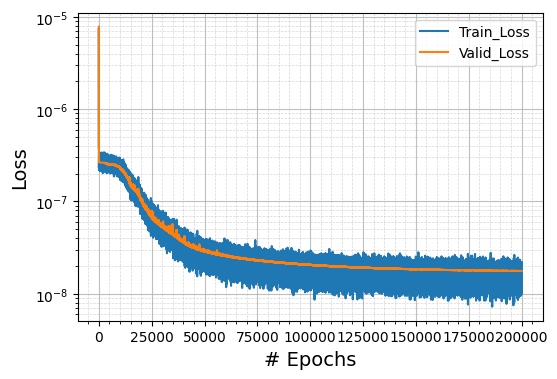

In [27]:
fig, ax = plt.subplots(figsize=(6,4))
loss_plot(ax,train_loss,'Train_Loss',1)
loss_plot(ax,valid_loss,'Valid_Loss',1)

In [28]:
fig.savefig("loss_burger_2d.png",dpi=300)

## Inference

In [29]:
# Uploading the best optimized parameters
with open("ti_don_2d_burger.pkl", "rb") as f:
    params = pickle.load(f)
p = 100
branch_features = [256,128]+[p]
trunk_features = [128]*4+[p]
model = DeepONet(branch_features=branch_features, trunk_features=trunk_features)

In [30]:
test_sample = jnp.arange(0,data_test.shape[0])
ns = len(test_sample)
X = grid
u_test = data_test[test_sample,:,:]
branch_test = data_test[test_sample,0,:,:].reshape(-1,nx,ny)
trunk_test = grid

In [31]:
branch_test.shape,grid.shape,u_test.shape

((250, 32, 32), (1024, 2), (250, 101, 32, 32))

In [ ]:
# Using DeepONet+RK4 to predict 
u_pred = jnp.zeros((ns, nt, nx,ny))
u_pred = u_pred.at[:, 0, :,:].set(branch_test)
for i in range(1, nt):
    umodel = RK4(params,branch_test,trunk_test)
    #print(umodel.shape)
    branch_test = umodel.reshape(-1,nx,ny)
    u_pred = u_pred.at[:, i, :,:].set(umodel.reshape(ns,nx,ny))

In [33]:
#u_test = data_test[0:3,:,:]
u_pred.shape,branch_test.shape,u_test.shape

((250, 101, 32, 32), (250, 32, 32), (250, 101, 32, 32))

In [34]:
np.linalg.norm(u_pred - u_test)/np.linalg.norm(u_test)

np.float32(0.12998907)

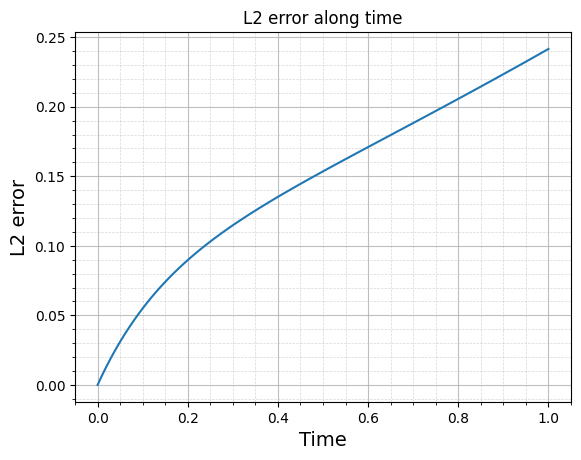

In [24]:
# Plot of L2 error for each time step
l2_error = []
for i in range(nt):
    l2_error.append(np.linalg.norm(u_pred[:,i,:] - u_test[:,i,:])/np.linalg.norm(u_test[:,i,:]))
plt.plot(jnp.linspace(0,1,nt),jnp.array(l2_error))
plt.xlabel("Time",fontsize = 14)
plt.ylabel("L2 error",fontsize = 14)
plt.title("L2 error along time")
plt.grid(which='major', linestyle='-', axis = 'both', linewidth=0.8, alpha=0.8)
plt.grid(which='minor', linestyle='--',axis = 'both', linewidth=0.5, alpha=0.5)
plt.minorticks_on()

In [ ]:
# Plot of L2 error for each time step
l2_error_1 = []
for i in range(dim_t):
    l2_error_1.append(np.linalg.norm(u_pred[10,i,:] - u_test[10,i,:])/np.linalg.norm(u_test[10,i,:]))
plt.plot(jnp.linspace(0,1,dim_t),jnp.array(l2_error_1))
plt.xlabel("Time",fontsize = 14)
plt.ylabel("L2 error",fontsize = 14)
plt.title("L2 error along time")
plt.grid(which='major', linestyle='-', axis = 'both', linewidth=0.8, alpha=0.8)
plt.grid(which='minor', linestyle='--',axis = 'both', linewidth=0.5, alpha=0.5)
plt.minorticks_on()

In [ ]:
u_error = abs(u_test-u_pred)
u_error.shape

In [ ]:
# Contour map of one sample
k = 300
x = jnp.linspace(0,1,101)
t = jnp.linspace(0,1,101)
fig,axs = plt.subplots(1,3,figsize = (15,4))
pcm1 = axs[0].pcolormesh(t,x,u_test[k], cmap='jet', shading='auto')
fig.colorbar(pcm1,ax=axs[0])
axs[0].set_xlabel("t",fontsize = 14)
axs[0].set_ylabel("x",fontsize = 14)
axs[0].set_title("True Solution")
pcm2 = axs[1].pcolormesh(t,x,u_pred[k], cmap='jet', shading='auto')
fig.colorbar(pcm2,ax=axs[1])
axs[1].set_xlabel("t",fontsize = 14)
axs[1].set_ylabel("x",fontsize = 14)
axs[1].set_title("Predicted Solution")
pcm3 = axs[2].pcolormesh(t,x,u_error[k], cmap='Greys', shading='auto')
fig.colorbar(pcm3,ax=axs[2])
axs[2].set_xlabel("t",fontsize = 14)
axs[2].set_ylabel("x",fontsize = 14)
axs[2].set_title("Error in Solution")

fig.show()